In [29]:
import os
import gc
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)
import lightgbm as lgb

In [8]:
# TensorFlow/Keras para feature extraction
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Configurar TensorFlow para usar menos memoria
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(f"GPU config error: {e}")

print("=" * 80)
print("🚀 LIGHTGBM CON FEATURE EXTRACTION - FOOD-101 DESAYUNO")
print("=" * 80)

🚀 LIGHTGBM CON FEATURE EXTRACTION - FOOD-101 DESAYUNO


In [9]:

# ============================================================================
# PARTE 1: CARGAR DATASET PREPROCESADO
# ============================================================================

import os
import zipfile
import pickle
import numpy as np
import gdown

# Configuración: usa el enlace correcto de Google Drive
DRIVE_URL = 'https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE'  # Cambia por tu ID
ZIP_PATH = '/content/desayuno_preprocessed_archive.zip'
DATASET_DIR = '/content/desayuno_preprocessed'

# Descargar desde Google Drive
print("Descargando ZIP desde Google Drive...")
try:
    gdown.download(DRIVE_URL, ZIP_PATH, quiet=False)
except Exception as e:
    print(f"Error al descargar: {e}")
    print("Verifica el enlace de Google Drive o sube el ZIP manualmente")
    raise

# Verificar tamaño del archivo
if os.path.getsize(ZIP_PATH) < 1000000:  # Menos de 1 MB
    print("Error: El archivo descargado es demasiado pequeño, probablemente no es el ZIP correcto")
    raise ValueError("Archivo descargado no válido")

# Descomprimir ZIP
try:
    os.makedirs(DATASET_DIR, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(DATASET_DIR)
    print(f"Descomprimido en: {DATASET_DIR}")
except zipfile.BadZipFile:
    print("Error: El archivo descargado no es un ZIP válido")
    print("Verifica que el archivo en Google Drive sea correcto (170.56 MB)")
    raise

# Cargar pickle
PKL_PATH = os.path.join(DATASET_DIR, 'food101_desayuno_preprocessed.pkl')
with open(PKL_PATH, 'rb') as f:
    data = pickle.load(f)
npz_files = data['npz_files']
class_names = data['class_names']

# Cargar datos
X, y = [], []
for npz_file in npz_files:
    with np.load(os.path.join(DATASET_DIR, npz_file)) as npz:
        X.append(npz['X'])
        y.append(npz['y'])
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

print(f"Dataset cargado: Imágenes {X.shape}, Etiquetas {y.shape}")
# Usa X y y en el modelo (ejemplo: modelo.fit(X.reshape(X.shape[0], -1), y))

Descargando ZIP desde Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE
From (redirected): https://drive.google.com/uc?id=1ReMjp7GNUz1cm2o-V8nDDdtAO9shnUtE&confirm=t&uuid=bf6264d4-0678-4d54-b188-2fab4919f6f2
To: /content/desayuno_preprocessed_archive.zip
100%|██████████| 179M/179M [00:01<00:00, 125MB/s]


Descomprimido en: /content/desayuno_preprocessed
Dataset cargado: Imágenes (20960, 48, 48, 3), Etiquetas (20960,)


In [10]:
# ============================================================================
# PARTE 2: SPLIT TRAIN/TEST (80/20)
# ============================================================================

print("\n[PASO 2] Dividiendo dataset en train/test (80/20)...")
print("-" * 80)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # Mantener proporción de clases
)

print(f"✅ Split completado:")
print(f"   • Train: {X_train.shape[0]:,} imágenes ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   • Test:  {X_test.shape[0]:,} imágenes ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verificar distribución de clases
train_dist = np.bincount(y_train)
test_dist = np.bincount(y_test)

print(f"\n📊 Distribución por clase (Train/Test):")
for i, class_name in enumerate(class_names):
    if i < len(train_dist):
        print(f"   {class_name:25s}: {train_dist[i]:4d} / {test_dist[i]:4d}")


[PASO 2] Dividiendo dataset en train/test (80/20)...
--------------------------------------------------------------------------------
✅ Split completado:
   • Train: 16,768 imágenes (80.0%)
   • Test:  4,192 imágenes (20.0%)

📊 Distribución por clase (Train/Test):
   apple_pie                :  798 /  200
   beignets                 :  798 /  199
   bread_pudding            :  797 /  199
   breakfast_burrito        :  799 /  200
   cannoli                  :  799 /  199
   carrot_cake              :  798 /  200
   cheesecake               :  799 /  199
   chocolate_cake           :  800 /  200
   churros                  :  783 /  196
   club_sandwich            :  799 /  200
   croque_madame            :  799 /  200
   cup_cakes                :  799 /  200
   donuts                   :  800 /  200
   eggs_benedict            :  800 /  200
   french_toast             :  800 /  200
   grilled_cheese_sandwich  :  800 /  200
   huevos_rancheros         :  800 /  200
   omelette         

In [11]:
# ============================================================================
# PARTE 3: FEATURE EXTRACTION CON MOBILENETV2
# ============================================================================

print("\n[PASO 3] Extrayendo features con MobileNetV2...")
print("-" * 80)

# Cargar MobileNetV2 preentrenado (sin top layer)
print("🔧 Cargando MobileNetV2 preentrenado...")
feature_extractor = MobileNetV2(
    weights='imagenet',
    include_top=False,  # Sin clasificador
    pooling='avg',      # Global Average Pooling
    input_shape=(48, 48, 3)
)

print(f"✅ Modelo cargado")
print(f"   • Output shape: {feature_extractor.output_shape}")
print(f"   • Features dim: {feature_extractor.output_shape[1]}")

# Función para extraer features en batches
def extract_features_batch(images, batch_size=64):
    """Extrae features en batches para eficiencia de memoria"""
    n_samples = len(images)
    n_batches = (n_samples + batch_size - 1) // batch_size
    features_list = []

    for i in tqdm(range(n_batches), desc="Extracting features"):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, n_samples)
        batch = images[start_idx:end_idx]

        # Preprocesar para MobileNetV2
        batch_preprocessed = preprocess_input(batch * 255.0)

        # Extraer features
        batch_features = feature_extractor.predict(batch_preprocessed, verbose=0)
        features_list.append(batch_features)

        # Limpiar memoria cada 5 batches
        if i % 5 == 0:
            gc.collect()

    return np.vstack(features_list)

# Extraer features para train y test
print("\n🔄 Extrayendo features de TRAIN...")
X_train_features = extract_features_batch(X_train, batch_size=64)

print("\n🔄 Extrayendo features de TEST...")
X_test_features = extract_features_batch(X_test, batch_size=64)

print(f"\n✅ Features extraídas:")
print(f"   • Train features shape: {X_train_features.shape}")
print(f"   • Test features shape:  {X_test_features.shape}")

# Liberar memoria de imágenes originales
del X, X_train, X_test
gc.collect()



[PASO 3] Extrayendo features con MobileNetV2...
--------------------------------------------------------------------------------
🔧 Cargando MobileNetV2 preentrenado...


/tmp/ipython-input-2664550484.py:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  feature_extractor = MobileNetV2(


✅ Modelo cargado
   • Output shape: (None, 1280)
   • Features dim: 1280

🔄 Extrayendo features de TRAIN...


Extracting features: 100%|██████████| 262/262 [01:35<00:00,  2.74it/s]



🔄 Extrayendo features de TEST...


Extracting features: 100%|██████████| 66/66 [00:25<00:00,  2.55it/s]



✅ Features extraídas:
   • Train features shape: (16768, 1280)
   • Test features shape:  (4192, 1280)


0

In [15]:
# ============================================================================
# PARTE 4: ENTRENAR LIGHTGBM
# ============================================================================

print("\n[PASO 4] Entrenando modelo LightGBM...")
print("-" * 80)

# Hiperparámetros optimizados para multiclass
lgb_params = {
    'objective': 'multiclass',
    'num_class': len(class_names),
    'metric': 'multi_logloss',
    'boosting_type': 'gbdt',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'max_depth': 7,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

print(f"⚙️ Hiperparámetros:")
for key, value in lgb_params.items():
    print(f"   {key:20s}: {value}")

# Crear datasets de LightGBM
print("\n📦 Creando datasets LightGBM...")
train_data = lgb.Dataset(X_train_features, label=y_train)
test_data = lgb.Dataset(X_test_features, label=y_test, reference=train_data)

# Entrenar modelo
print("\n🚀 Entrenando modelo...")
evals_result = {}

model = lgb.train(
    lgb_params,
    train_data,
    num_boost_round=500,
    valid_sets=[train_data, test_data],
    valid_names=['train', 'test'],
    callbacks=[
        lgb.log_evaluation(period=50),
        lgb.early_stopping(stopping_rounds=50),
        lgb.record_evaluation(evals_result)
    ]
)

print(f"\n✅ Entrenamiento completado")
print(f"   • Mejor iteración: {model.best_iteration}")
print(f"   • Train loss: {evals_result['train']['multi_logloss'][-1]:.4f}")
print(f"   • Test loss:  {evals_result['test']['multi_logloss'][-1]:.4f}")


[PASO 4] Entrenando modelo LightGBM...
--------------------------------------------------------------------------------
⚙️ Hiperparámetros:
   objective           : multiclass
   num_class           : 21
   metric              : multi_logloss
   boosting_type       : gbdt
   learning_rate       : 0.05
   num_leaves          : 31
   max_depth           : 7
   min_child_samples   : 20
   subsample           : 0.8
   colsample_bytree    : 0.8
   reg_alpha           : 0.1
   reg_lambda          : 0.1
   random_state        : 42
   verbose             : -1
   n_jobs              : -1

📦 Creando datasets LightGBM...

🚀 Entrenando modelo...
Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 1.20232	test's multi_logloss: 2.45475
[100]	train's multi_logloss: 0.648883	test's multi_logloss: 2.37352
[150]	train's multi_logloss: 0.365478	test's multi_logloss: 2.35329
[200]	train's multi_logloss: 0.204518	test's multi_logloss: 2.35657
Early stopping, best itera

In [30]:
# ============================================================================
# PARTE 4.1: VALIDACIÓN CRUZADA CON STRATIFIEDKFOLD
# ============================================================================

print("\n[PASO 4.1] Validación cruzada con StratifiedKFold...")
print("-" * 80)

# Configurar StratifiedKFold
n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

# Listas para almacenar métricas
cv_scores = {
    'accuracy': [],
    'f1_macro': [],
    'f1_weighted': [],
    'multi_logloss': []
}

# Validación cruzada
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_features, y_train), 1):
    print(f"\n🔄 Fold {fold}/{n_folds}")

    # Crear datasets para el fold
    X_train_fold = X_train_features[train_idx]
    y_train_fold = y_train[train_idx]
    X_val_fold = X_train_features[val_idx]
    y_val_fold = y_train[val_idx]

    train_data_fold = lgb.Dataset(X_train_fold, label=y_train_fold)
    val_data_fold = lgb.Dataset(X_val_fold, label=y_val_fold, reference=train_data_fold)

    # Entrenar modelo para este fold
    model_fold = lgb.train(
        lgb_params,
        train_data_fold,
        num_boost_round=500,
        valid_sets=[train_data_fold, val_data_fold],
        valid_names=['train', 'val'],
        callbacks=[
            lgb.log_evaluation(period=0),  # Silenciar logs
            lgb.early_stopping(stopping_rounds=50, verbose=False)
        ]
    )

    # Predicciones en validación
    y_pred_proba = model_fold.predict(X_val_fold)
    y_pred = np.argmax(y_pred_proba, axis=1)

    # Calcular métricas
    accuracy = accuracy_score(y_val_fold, y_pred)
    f1_macro = f1_score(y_val_fold, y_pred, average='macro')
    f1_weighted = f1_score(y_val_fold, y_pred, average='weighted')
    logloss = model_fold.best_score['val']['multi_logloss']

    cv_scores['accuracy'].append(accuracy)
    cv_scores['f1_macro'].append(f1_macro)
    cv_scores['f1_weighted'].append(f1_weighted)
    cv_scores['multi_logloss'].append(logloss)

    print(f"   • Accuracy: {accuracy:.4f}")
    print(f"   • F1-Score Macro: {f1_macro:.4f}")
    print(f"   • F1-Score Weighted: {f1_weighted:.4f}")
    print(f"   • Multi-LogLoss: {logloss:.4f}")

# Resumen de resultados
print(f"\n📊 Resultados de validación cruzada (promedio ± std):")
print(f"   • Accuracy:       {np.mean(cv_scores['accuracy']):.4f} ± {np.std(cv_scores['accuracy']):.4f}")
print(f"   • F1-Score Macro: {np.mean(cv_scores['f1_macro']):.4f} ± {np.std(cv_scores['f1_macro']):.4f}")
print(f"   • F1-Score Weighted: {np.mean(cv_scores['f1_weighted']):.4f} ± {np.std(cv_scores['f1_weighted']):.4f}")
print(f"   • Multi-LogLoss:  {np.mean(cv_scores['multi_logloss']):.4f} ± {np.std(cv_scores['multi_logloss']):.4f}")


[PASO 4.1] Validación cruzada con StratifiedKFold...
--------------------------------------------------------------------------------

🔄 Fold 1/5
   • Accuracy: 0.2865
   • F1-Score Macro: 0.2843
   • F1-Score Weighted: 0.2842
   • Multi-LogLoss: 2.3758

🔄 Fold 2/5
   • Accuracy: 0.2999
   • F1-Score Macro: 0.2970
   • F1-Score Weighted: 0.2970
   • Multi-LogLoss: 2.3766

🔄 Fold 3/5
   • Accuracy: 0.2949
   • F1-Score Macro: 0.2903
   • F1-Score Weighted: 0.2904
   • Multi-LogLoss: 2.3632

🔄 Fold 4/5
   • Accuracy: 0.2956
   • F1-Score Macro: 0.2926
   • F1-Score Weighted: 0.2926
   • Multi-LogLoss: 2.3452

🔄 Fold 5/5
   • Accuracy: 0.2845
   • F1-Score Macro: 0.2809
   • F1-Score Weighted: 0.2808
   • Multi-LogLoss: 2.3819

📊 Resultados de validación cruzada (promedio ± std):
   • Accuracy:       0.2923 ± 0.0058
   • F1-Score Macro: 0.2890 ± 0.0058
   • F1-Score Weighted: 0.2890 ± 0.0058
   • Multi-LogLoss:  2.3686 ± 0.0132


In [16]:
# ============================================================================
# PARTE 5: EVALUACIÓN DEL MODELO
# ============================================================================

print("\n[PASO 5] Evaluando modelo...")
print("-" * 80)

# Predicciones
y_pred_proba = model.predict(X_test_features)
y_pred = np.argmax(y_pred_proba, axis=1)

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f"\n📊 Métricas principales:")
print(f"   • Accuracy:       {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • F1-Score Macro: {f1_macro:.4f}")
print(f"   • F1-Score Weighted: {f1_weighted:.4f}")

# Classification report
print(f"\n📋 Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=class_names,
    digits=3
))



[PASO 5] Evaluando modelo...
--------------------------------------------------------------------------------

📊 Métricas principales:
   • Accuracy:       0.2987 (29.87%)
   • F1-Score Macro: 0.2952
   • F1-Score Weighted: 0.2951

📋 Classification Report:
                         precision    recall  f1-score   support

              apple_pie      0.229     0.205     0.216       200
               beignets      0.495     0.518     0.506       199
          bread_pudding      0.216     0.181     0.197       199
      breakfast_burrito      0.161     0.120     0.138       200
                cannoli      0.347     0.347     0.347       199
            carrot_cake      0.270     0.240     0.254       200
             cheesecake      0.297     0.261     0.278       199
         chocolate_cake      0.392     0.370     0.380       200
                churros      0.316     0.332     0.323       196
          club_sandwich      0.380     0.500     0.432       200
          croque_madame   


[PASO 6] Generando visualizaciones...
--------------------------------------------------------------------------------
✅ Guardado en Colab: /content/lightgbm_results.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descargando lightgbm_results.png a tu ordenador...


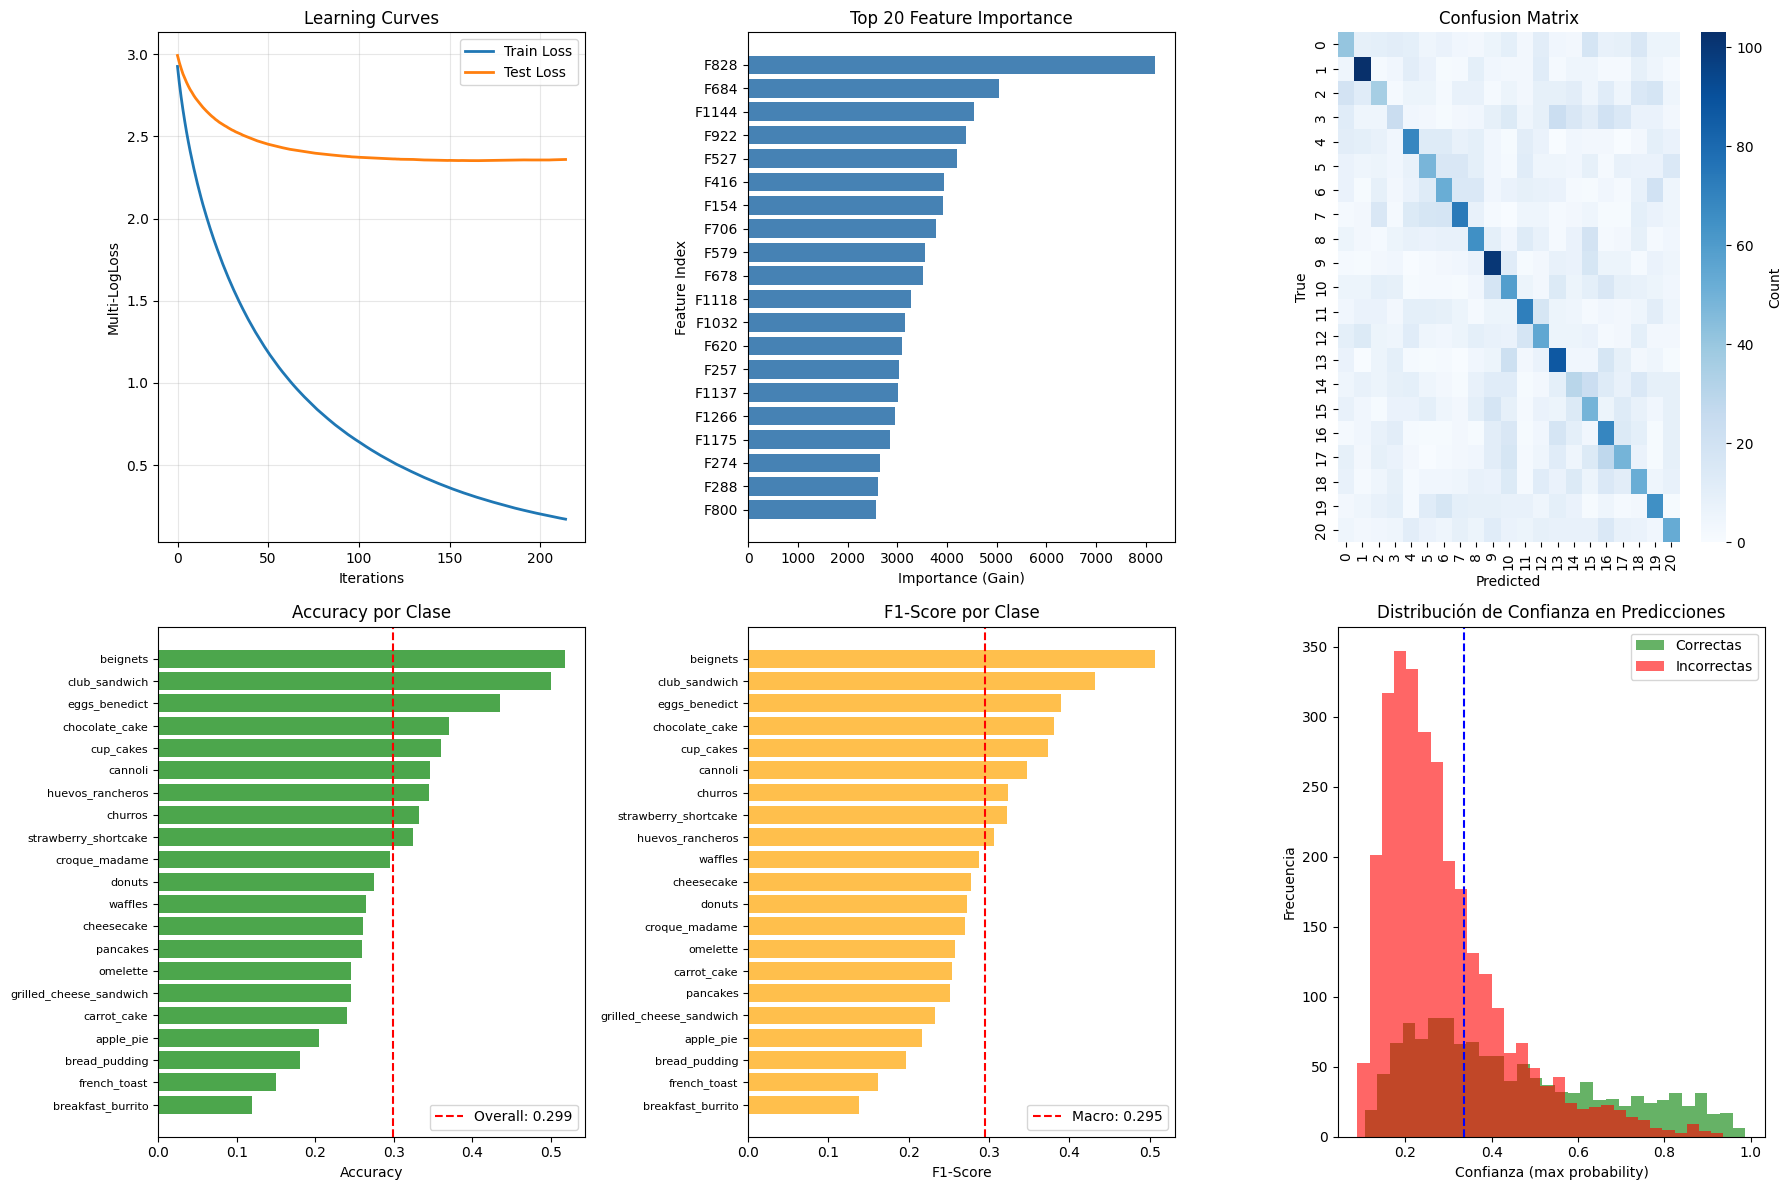

In [20]:
# ============================================================================
# PARTE 6: VISUALIZACIONES
# ============================================================================

print("\n[PASO 6] Generando visualizaciones...")
print("-" * 80)

fig = plt.figure(figsize=(18, 12))

# 1. Curvas de aprendizaje
ax1 = plt.subplot(2, 3, 1)
train_loss = evals_result['train']['multi_logloss']
test_loss = evals_result['test']['multi_logloss']
ax1.plot(train_loss, label='Train Loss', linewidth=2)
ax1.plot(test_loss, label='Test Loss', linewidth=2)
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Multi-LogLoss')
ax1.set_title('Learning Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Feature Importance (Top 20)
ax2 = plt.subplot(2, 3, 2)
importance = model.feature_importance(importance_type='gain')
top_features_idx = np.argsort(importance)[-20:]
ax2.barh(range(20), importance[top_features_idx], color='steelblue')
ax2.set_xlabel('Importance (Gain)')
ax2.set_ylabel('Feature Index')
ax2.set_title('Top 20 Feature Importance')
ax2.set_yticks(range(20))
ax2.set_yticklabels([f'F{i}' for i in top_features_idx])

# 3. Matriz de confusión
ax3 = plt.subplot(2, 3, 3)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=ax3, cbar_kws={'label': 'Count'})
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')
ax3.set_title('Confusion Matrix')

# 4. Accuracy por clase
ax4 = plt.subplot(2, 3, 4)
class_accuracies = []
for i in range(len(class_names)):
    mask = y_test == i
    if mask.sum() > 0:
        acc = (y_pred[mask] == i).sum() / mask.sum()
        class_accuracies.append(acc)
    else:
        class_accuracies.append(0)

sorted_idx = np.argsort(class_accuracies)
ax4.barh(range(len(class_names)), np.array(class_accuracies)[sorted_idx], color='green', alpha=0.7)
ax4.set_xlabel('Accuracy')
ax4.set_title('Accuracy por Clase')
ax4.set_yticks(range(len(class_names)))
ax4.set_yticklabels([class_names[i] for i in sorted_idx], fontsize=8)
ax4.axvline(accuracy, color='red', linestyle='--', label=f'Overall: {accuracy:.3f}')
ax4.legend()

# 5. F1-Score por clase
ax5 = plt.subplot(2, 3, 5)
f1_per_class = f1_score(y_test, y_pred, average=None)
sorted_f1_idx = np.argsort(f1_per_class)
ax5.barh(range(len(class_names)), f1_per_class[sorted_f1_idx], color='orange', alpha=0.7)
ax5.set_xlabel('F1-Score')
ax5.set_title('F1-Score por Clase')
ax5.set_yticks(range(len(class_names)))
ax5.set_yticklabels([class_names[i] for i in sorted_f1_idx], fontsize=8)
ax5.axvline(f1_macro, color='red', linestyle='--', label=f'Macro: {f1_macro:.3f}')
ax5.legend()

# 6. Distribución de confianza en predicciones
ax6 = plt.subplot(2, 3, 6)
max_proba = np.max(y_pred_proba, axis=1)
correct_mask = y_pred == y_test
ax6.hist(max_proba[correct_mask], bins=30, alpha=0.6, label='Correctas', color='green')
ax6.hist(max_proba[~correct_mask], bins=30, alpha=0.6, label='Incorrectas', color='red')
ax6.set_xlabel('Confianza (max probability)')
ax6.set_ylabel('Frecuencia')
ax6.set_title('Distribución de Confianza en Predicciones')
ax6.legend()
ax6.axvline(max_proba.mean(), color='blue', linestyle='--', label=f'Media: {max_proba.mean():.3f}')

plt.tight_layout()

# GUARDAR EN MÚLTIPLES UBICACIONES
# ============================================

# 1. GUARDAR EN COLAB
colab_path = '/content/lightgbm_results.png'
plt.savefig(colab_path, dpi=150, bbox_inches='tight')
print(f"✅ Guardado en Colab: {colab_path}")

# 2. DESCARGAR A TU ORDENADOR (Colab)
try:
    from google.colab import files
    files.download(colab_path)
    print("✅ Descargando lightgbm_results.png a tu ordenador...")
except ImportError:
    print("⚠️ No estás en Colab, descarga omitida")

# 3. GUARDAR EN CARPETA LOCAL (Visual Studio Code / Local)
# DESCOMENTA ESTAS LÍNEAS SI TRABAJAS EN VISUAL STUDIO CODE:
# local_path = './outputs/lightgbm_results.png'
# os.makedirs('./outputs', exist_ok=True)
# plt.savefig(local_path, dpi=150, bbox_inches='tight')
# print(f"✅ Guardado localmente: {local_path}")

plt.show()


In [23]:
print("Archivos en /content:")
for file in os.listdir('/content'):
    print(file)

import os

print(f"Tamaño de lightgbm_food_model.txt: {os.path.getsize('/content/lightgbm_food_model.txt') / 1024 / 1024:.2f} MB")
print(f"Tamaño de model_metadata.pkl: {os.path.getsize('/content/model_metadata.pkl') / 1024 / 1024:.2f} MB")
print(f"Tamaño de lightgbm_model_package.zip: {os.path.getsize('/content/lightgbm_model_package.zip') / 1024 / 1024:.2f} MB")

Archivos en /content:
.config
desayuno_preprocessed_archive.zip
desayuno_preprocessed
model_metadata.pkl
lightgbm_results.png
lightgbm_model_package.zip
lightgbm_food_model.txt
sample_data
Tamaño de lightgbm_food_model.txt: 11.46 MB
Tamaño de model_metadata.pkl: 0.00 MB
Tamaño de lightgbm_model_package.zip: 32349.86 MB


In [25]:
# ============================================================================
# PARTE 7: GUARDAR MODELO
# ============================================================================

print("\n[PASO 7] Guardando modelo...")
print("-" * 80)

# GUARDAR EN MÚLTIPLES UBICACIONES
# ============================================

# 1. GUARDAR EN COLAB
colab_model_path = '/content/lightgbm_food_model.txt'
model.save_model(colab_model_path)
print(f"✅ Modelo guardado en Colab: {colab_model_path}")

colab_metadata_path = '/content/model_metadata.pkl'
metadata = {
    'class_names': class_names,
    'n_classes': len(class_names),
    'feature_dim': X_train_features.shape[1],
    'accuracy': float(accuracy),
    'f1_macro': float(f1_macro),
    'f1_weighted': float(f1_weighted),
    'best_iteration': model.best_iteration,
    'lgb_params': lgb_params
}

with open(colab_metadata_path, 'wb') as f:
    pickle.dump(metadata, f)
print(f"✅ Metadata guardada en Colab: {colab_metadata_path}")

# 2. DESCARGAR A TU ORDENADOR (Colab)
# try:
#     from google.colab import files
#     files.download(colab_model_path)
#     files.download(colab_metadata_path)
#     print("✅ Descargando archivos del modelo a tu ordenador...")
# except ImportError:
#     print("⚠️ No estás en Colab, descarga omitida")

# 3. GUARDAR EN CARPETA LOCAL (Visual Studio Code / Local)
# DESCOMENTA ESTAS LÍNEAS SI TRABAJAS EN VISUAL STUDIO CODE:
# local_model_dir = './outputs'
# os.makedirs(local_model_dir, exist_ok=True)
#
# local_model_path = os.path.join(local_model_dir, 'lightgbm_food_model.txt')
# model.save_model(local_model_path)
# print(f"✅ Modelo guardado localmente: {local_model_path}")
#
# local_metadata_path = os.path.join(local_model_dir, 'model_metadata.pkl')
# with open(local_metadata_path, 'wb') as f:
#     pickle.dump(metadata, f)
# print(f"✅ Metadata guardada localmente: {local_metadata_path}")

# CREAR ZIP CON TODO (OPCIONAL)
# ============================================
# import shutil

# # Colab: Comprimir y descargar
# zip_path = '/content/lightgbm_model_package'
# shutil.make_archive(zip_path, 'zip', '/content', base_dir=None)
# print(f"✅ Archivos comprimidos: {zip_path}.zip")

# try:
#     from google.colab import files
#     files.download(f"{zip_path}.zip")
#     print("✅ Descargando lightgbm_model_package.zip a tu ordenador...")
# except ImportError:
#     print("⚠️ No estás en Colab, descarga ZIP omitida")

# Visual Studio Code / Local: Comprimir en carpeta outputs
# DESCOMENTA ESTAS LÍNEAS SI TRABAJAS EN VISUAL STUDIO CODE:
# local_zip_path = './lightgbm_model_package'
# shutil.make_archive(local_zip_path, 'zip', './outputs')
# print(f"✅ ZIP creado localmente: {local_zip_path}.zip")


[PASO 7] Guardando modelo...
--------------------------------------------------------------------------------
✅ Modelo guardado en Colab: /content/lightgbm_food_model.txt
✅ Metadata guardada en Colab: /content/model_metadata.pkl


In [26]:
# ============================================================================
# PARTE 8: ANÁLISIS DE ERRORES
# ============================================================================

print("\n[PASO 8] Análisis de errores...")
print("-" * 80)

# Top 5 clases más confundidas
errors_df = pd.DataFrame({
    'true_label': y_test[y_pred != y_test],
    'pred_label': y_pred[y_pred != y_test]
})

if len(errors_df) > 0:
    confusion_pairs = errors_df.groupby(['true_label', 'pred_label']).size().reset_index(name='count')
    confusion_pairs = confusion_pairs.sort_values('count', ascending=False).head(10)

    print("\n🔍 Top 10 confusiones más frecuentes:")
    for idx, row in confusion_pairs.iterrows():
        true_class = class_names[int(row['true_label'])]
        pred_class = class_names[int(row['pred_label'])]
        count = int(row['count'])
        print(f"   {true_class:25s} → {pred_class:25s}: {count} veces")



[PASO 8] Análisis de errores...
--------------------------------------------------------------------------------

🔍 Top 10 confusiones más frecuentes:
   omelette                  → huevos_rancheros         : 28 veces
   breakfast_burrito         → eggs_benedict            : 23 veces
   french_toast              → grilled_cheese_sandwich  : 23 veces
   eggs_benedict             → croque_madame            : 22 veces
   breakfast_burrito         → huevos_rancheros         : 20 veces
   cheesecake                → strawberry_shortcake     : 20 veces
   churros                   → grilled_cheese_sandwich  : 19 veces
   bread_pudding             → apple_pie                : 19 veces
   apple_pie                 → grilled_cheese_sandwich  : 18 veces
   bread_pudding             → strawberry_shortcake     : 18 veces


In [27]:
# ============================================================================
# RESUMEN FINAL
# ============================================================================

print("\n" + "=" * 80)
print("✅ ENTRENAMIENTO COMPLETADO")
print("=" * 80)

print(f"\n📊 Resumen del modelo:")
print(f"   • Arquitectura: MobileNetV2 (feature extraction) + LightGBM")
print(f"   • Feature dimension: {X_train_features.shape[1]}")
print(f"   • Número de clases: {len(class_names)}")
print(f"   • Imágenes train: {len(y_train):,}")
print(f"   • Imágenes test: {len(y_test):,}")
print(f"   • Mejor iteración: {model.best_iteration}")

print(f"\n📈 Resultados:")
print(f"   • Accuracy:       {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   • F1-Score Macro: {f1_macro:.4f}")
print(f"   • F1-Score Weighted: {f1_weighted:.4f}")

print(f"\n💾 Archivos generados:")
print(f"   • lightgbm_food_model.txt - Modelo entrenado")
print(f"   • model_metadata.pkl - Metadata y parámetros")
print(f"   • lightgbm_results.png - Visualizaciones")

print("\n🚀 Para usar el modelo en producción:")
print("""
   1. Cargar modelo: model = lgb.Booster(model_file='lightgbm_food_model.txt')
   2. Extraer features de nueva imagen con MobileNetV2
   3. Predecir: proba = model.predict(features)
   4. Clase: argmax(proba)
""")

print("\n" + "=" * 80 + "\n")


✅ ENTRENAMIENTO COMPLETADO

📊 Resumen del modelo:
   • Arquitectura: MobileNetV2 (feature extraction) + LightGBM
   • Feature dimension: 1280
   • Número de clases: 21
   • Imágenes train: 16,768
   • Imágenes test: 4,192
   • Mejor iteración: 165

📈 Resultados:
   • Accuracy:       0.2987 (29.87%)
   • F1-Score Macro: 0.2952
   • F1-Score Weighted: 0.2951

💾 Archivos generados:
   • lightgbm_food_model.txt - Modelo entrenado
   • model_metadata.pkl - Metadata y parámetros
   • lightgbm_results.png - Visualizaciones

🚀 Para usar el modelo en producción:

   1. Cargar modelo: model = lgb.Booster(model_file='lightgbm_food_model.txt')
   2. Extraer features de nueva imagen con MobileNetV2
   3. Predecir: proba = model.predict(features)
   4. Clase: argmax(proba)



